d01 nearest index = (205, 362), distance = 0.870 km
d02 nearest index = (206, 348), distance = 0.191 km


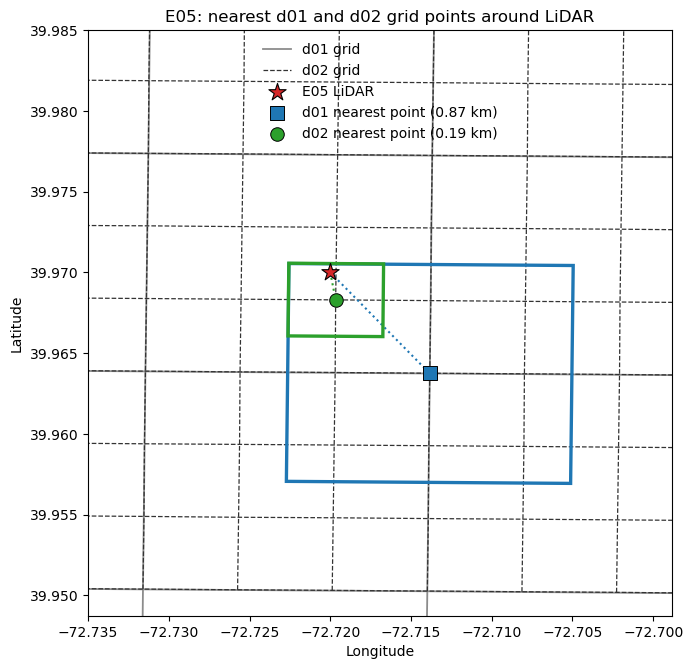

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# -------------------------------------------------
# USER INPUT
# -------------------------------------------------
d01_file = "/glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/era5_3dpbl/wrfout_d02_2020-05-15_15:00:00"
d02_file = "/glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/era5_3dpbl/wrfout_d03_2020-05-15_15:00:00"

# Example: E05
lidar_lon = -72.72
lidar_lat = 39.97
lidar_label = "E05"

# If you want E06 instead:
# lidar_lon = -73.43
# lidar_lat = 39.55
# lidar_label = "E06"


# -------------------------------------------------
# HELPERS
# -------------------------------------------------
def get_latlon(ds):
    lats = ds["XLAT"]
    lons = ds["XLONG"]

    if "Time" in lats.dims:
        lats = lats.isel(Time=0)
    if "Time" in lons.dims:
        lons = lons.isel(Time=0)

    return np.asarray(lons), np.asarray(lats)


def nearest_grid_point(lons, lats, target_lon, target_lat):
    """
    Find nearest WRF mass-grid point using the same idea as your code.
    """
    km_lon = 85.0
    km_lat = 111.0

    latdiff_km = np.abs(lats - target_lat) * km_lat
    londiff_km = np.abs(lons - target_lon) * km_lon
    dist_km = np.sqrt(latdiff_km**2 + londiff_km**2)

    j, i = np.where(dist_km == np.nanmin(dist_km))
    j = int(j[0])
    i = int(i[0])

    return j, i, dist_km[j, i]


def local_bounds(j, i, shape, buffer_pts):
    j0 = max(j - buffer_pts, 0)
    j1 = min(j + buffer_pts + 1, shape[0])
    i0 = max(i - buffer_pts, 0)
    i1 = min(i + buffer_pts + 1, shape[1])
    return j0, j1, i0, i1


def draw_grid(ax, lons, lats, j, i, buffer_pts, color="0.7", lw=1.0, ls="-", label=None):
    """
    Draw a local window of grid lines around (j,i).
    """
    j0, j1, i0, i1 = local_bounds(j, i, lats.shape, buffer_pts)

    # rows
    first = True
    for jj in range(j0, j1):
        ax.plot(
            lons[jj, i0:i1],
            lats[jj, i0:i1],
            color=color,
            linewidth=lw,
            linestyle=ls,
            label=label if first else None,
            zorder=1
        )
        first = False

    # columns
    for ii in range(i0, i1):
        ax.plot(
            lons[j0:j1, ii],
            lats[j0:j1, ii],
            color=color,
            linewidth=lw,
            linestyle=ls,
            zorder=1
        )


def get_cell_polygon(lons, lats, j, i):
    """
    Approximate polygon of a grid cell around a mass-grid point.
    Works best for interior points.
    """
    if j == 0 or i == 0 or j == lats.shape[0]-1 or i == lats.shape[1]-1:
        return None

    sw_lon = np.mean([lons[j, i], lons[j-1, i], lons[j, i-1], lons[j-1, i-1]])
    sw_lat = np.mean([lats[j, i], lats[j-1, i], lats[j, i-1], lats[j-1, i-1]])

    se_lon = np.mean([lons[j, i], lons[j-1, i], lons[j, i+1], lons[j-1, i+1]])
    se_lat = np.mean([lats[j, i], lats[j-1, i], lats[j, i+1], lats[j-1, i+1]])

    ne_lon = np.mean([lons[j, i], lons[j+1, i], lons[j, i+1], lons[j+1, i+1]])
    ne_lat = np.mean([lats[j, i], lats[j+1, i], lats[j, i+1], lats[j+1, i+1]])

    nw_lon = np.mean([lons[j, i], lons[j+1, i], lons[j, i-1], lons[j+1, i-1]])
    nw_lat = np.mean([lats[j, i], lats[j+1, i], lats[j, i-1], lats[j+1, i-1]])

    return np.array([
        [sw_lon, sw_lat],
        [se_lon, se_lat],
        [ne_lon, ne_lat],
        [nw_lon, nw_lat]
    ])


# -------------------------------------------------
# READ FILES
# -------------------------------------------------
ds1 = xr.open_dataset(d01_file, engine="netcdf4")
ds2 = xr.open_dataset(d02_file, engine="netcdf4")

lon1, lat1 = get_latlon(ds1)
lon2, lat2 = get_latlon(ds2)

# nearest points
j1, i1, dist1 = nearest_grid_point(lon1, lat1, lidar_lon, lidar_lat)
j2, i2, dist2 = nearest_grid_point(lon2, lat2, lidar_lon, lidar_lat)

print(f"d01 nearest index = ({j1}, {i1}), distance = {dist1:.3f} km")
print(f"d02 nearest index = ({j2}, {i2}), distance = {dist2:.3f} km")

# -------------------------------------------------
# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))

# smaller local grids only
d01_buf = 2
d02_buf = 4

draw_grid(ax, lon1, lat1, j1, i1, buffer_pts=d01_buf, color="0.55", lw=1.3, ls="-",  label="d01 grid")
draw_grid(ax, lon2, lat2, j2, i2, buffer_pts=d02_buf, color="0.20", lw=0.9, ls="--", label="d02 grid")

# optional cell outlines
poly1 = get_cell_polygon(lon1, lat1, j1, i1)
if poly1 is not None:
    ax.add_patch(Polygon(poly1, closed=True, fill=False, edgecolor="tab:blue", linewidth=2.4, zorder=3))

poly2 = get_cell_polygon(lon2, lat2, j2, i2)
if poly2 is not None:
    ax.add_patch(Polygon(poly2, closed=True, fill=False, edgecolor="tab:green", linewidth=2.4, zorder=4))

# lidar
ax.scatter(
    lidar_lon, lidar_lat,
    s=170, marker="*",
    color="tab:red",
    edgecolor="black",
    linewidth=0.8,
    label=f"{lidar_label} LiDAR",
    zorder=6
)

# nearest d01 point
ax.scatter(
    lon1[j1, i1], lat1[j1, i1],
    s=95, marker="s",
    color="tab:blue",
    edgecolor="black",
    linewidth=0.7,
    label=f"d01 nearest point ({dist1:.2f} km)",
    zorder=5
)

# nearest d02 point
ax.scatter(
    lon2[j2, i2], lat2[j2, i2],
    s=95, marker="o",
    color="tab:green",
    edgecolor="black",
    linewidth=0.7,
    label=f"d02 nearest point ({dist2:.2f} km)",
    zorder=5
)

# connection lines
ax.plot([lidar_lon, lon1[j1, i1]], [lidar_lat, lat1[j1, i1]],
        color="tab:blue", linestyle=":", linewidth=1.5, zorder=2)

ax.plot([lidar_lon, lon2[j2, i2]], [lidar_lat, lat2[j2, i2]],
        color="tab:green", linestyle=":", linewidth=1.5, zorder=2)

# -----------------------------------------
# TIGHTER LIMITS: focus only on main points
# -----------------------------------------
xpts = np.array([lidar_lon, lon1[j1, i1], lon2[j2, i2]])
ypts = np.array([lidar_lat, lat1[j1, i1], lat2[j2, i2]])

xmin, xmax = np.min(xpts), np.max(xpts)
ymin, ymax = np.min(ypts), np.max(ypts)

# small padding so things are visible
xrange_ = xmax - xmin
yrange_ = ymax - ymin

# fallback in case points are extremely close
if xrange_ == 0:
    xrange_ = 0.02
if yrange_ == 0:
    yrange_ = 0.02

pad_x = 0.8 * xrange_
pad_y = 0.8 * yrange_

# ensure a minimum visible area
pad_x = max(pad_x, 0.015)
pad_y = max(pad_y, 0.015)

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{lidar_label}: nearest d01 and d02 grid points around LiDAR")
ax.legend(frameon=False, loc="best")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

In [1]:
import os
import csv
import numpy as np                  # For doing math
import matplotlib.pyplot as plt     # For plotting
import matplotlib.dates as mdates   # For formatting dates when plotting
import matplotlib.colors as colors  # For truncating colorbars
import matplotlib.style as style
import xarray as xr                 # For dealing with netCDF data
import pandas as pd                 # A quick way to deal with time stamps
import netCDF4 as nc                # Another way to deal with netCDF data
import glob
import metpy.calc as mpcalc
import datetime
import matplotlib.units as munits
import scipy.interpolate
import scipy.signal as sig
import scipy.stats as stats
import sys
import scipy.io as sio

print('Should clean up redundancies')
from metpy.cbook import get_test_data
from metpy.plots import Hodograph, SkewT
from metpy.units import units
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
# from numpy.random import seed
# from numpy.random import rand

print('Done importing modules now')

import warnings
warnings.filterwarnings('ignore')

import matplotlib
from netCDF4 import Dataset
from xarray import DataArray
from wrf import (getvar, interplevel, vertcross, 
                 vinterp, ALL_TIMES, extract_global_attrs)
import cartopy.crs as ccrs          # For plotting maps
import cartopy.feature as cfeature  # For plotting maps
import datetime as dt

Should clean up redundancies
Done importing modules now


In [2]:
# Streamlined destagger

def destagger(var, stagger_dim):
    '''
    Modified From wrf-python https://github.com/NCAR/wrf-python/blob/b40d1d6e2d4aea3dd2dda03aae18e268b1e9291e/src/wrf/destag.py 
    '''
    var_shape = var.shape
    num_dims = var.ndim
    stagger_dim_size = var_shape[stagger_dim]

    full_slice = slice(None)
    slice1 = slice(0, stagger_dim_size - 1, 1)
    slice2 = slice(1, stagger_dim_size, 1)

    dim_ranges_1 = [full_slice] * num_dims
    dim_ranges_2 = [full_slice] * num_dims

    dim_ranges_1[stagger_dim] = slice1
    dim_ranges_2[stagger_dim] = slice2

    result = .5*(var[tuple(dim_ranges_1)] + var[tuple(dim_ranges_2)])

    return result

In [62]:
# ============================================================
# USER SETTINGS
# ============================================================

CASE_LABEL = "GFS MYNN"

RUN_DIRS = {
    "vert54": "/glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/gfs_mynn_vert54",
    "vert80": "/glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/gfs_mynn_vert80",
    "vert93": "/glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/gfs_mynn_vert93",
}

DOMAINS = ["d02", "d03"]

# LiDAR site
LIDAR_LABEL = "E05"
LIDAR_LON = -72.72
LIDAR_LAT = 39.97

# Observation file: 55 x 10 array
# Columns assumed: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200] m
OBS_FILE = "/glade/work/mhafsah/Analysis_Proj_1/WS_E05_OBS.npy"

HEIGHTS_M = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200], dtype=float)

# Heights to show directly
TOP_HEIGHT = 140
BOTTOM_HEIGHT = 60

# Time settings
DAY_STR = "2020-05-15"
START_HOUR = 14
END_HOUR = 23

# WRF files are hourly
WRF_DT_MINUTES = 60

# OBS is 10-minutely
OBS_DT_MINUTES = 10

# OBS_STRIDE = 1 plots all observed points
# OBS_STRIDE = 6 plots hourly observed points only
OBS_STRIDE = 1

# Output directory
OUT_DIR = f"./figures_{LIDAR_LABEL}_d02_d03_combined_WS_REWS"
os.makedirs(OUT_DIR, exist_ok=True)

In [43]:
# ============================================================
# PLOT STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.titlesize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Colors requested
COLOR_TOP_HEIGHT = "#003366"      # dark blue
COLOR_BOTTOM_HEIGHT = "#4B0082"   # dark purple
#COLOR_REWS = "#CC0000"            # red

# Line styles requested
STYLE_OBS = "-"
STYLE_D02 = "--"
STYLE_D03 = ":"   

In [44]:
# ============================================================
# TIME AND FILE HELPERS
# ============================================================

def make_times(day_str, start_hour, end_hour, dt_minutes):
    """
    Make datetime objects from start_hour to end_hour inclusive.
    """
    t0 = dt.datetime.strptime(
        f"{day_str} {start_hour:02d}:00:00",
        "%Y-%m-%d %H:%M:%S"
    )

    t1 = dt.datetime.strptime(
        f"{day_str} {end_hour:02d}:00:00",
        "%Y-%m-%d %H:%M:%S"
    )

    times = []
    t = t0

    while t <= t1:
        times.append(t)
        t += dt.timedelta(minutes=dt_minutes)

    return times


def wrfout_path(run_dir, dom, time_obj):
    """
    Build WRF output file path.

    Example:
    wrfout_d02_2020-05-15_15:00:00
    """
    ts = time_obj.strftime("%Y-%m-%d_%H:%M:%S")
    return os.path.join(run_dir, f"wrfout_{dom}_{ts}")


def get_first_existing_file(run_dir, dom, wrf_times):
    """
    Find first existing wrfout file for one run/domain.
    Used to read XLAT/XLONG and find nearest LiDAR grid point.
    """
    for t in wrf_times:
        f = wrfout_path(run_dir, dom, t)

        if os.path.exists(f):
            return f

    return None

In [45]:
# ============================================================
# GRID / LOCATION HELPERS
# ============================================================

def get_latlon(ds):
    """
    Read XLAT and XLONG.
    If Time dimension exists, use Time=0.
    """
    lats = ds["XLAT"]
    lons = ds["XLONG"]

    if "Time" in lats.dims:
        lats = lats.isel(Time=0)

    if "Time" in lons.dims:
        lons = lons.isel(Time=0)

    return np.asarray(lons), np.asarray(lats)


def nearest_grid_point(lons, lats, target_lon, target_lat):
    """
    Find nearest WRF mass-grid point to the LiDAR location.
    Same approximate-distance approach as your original extraction script.
    """
    km_lon = 85.0
    km_lat = 111.0

    latdiff_km = np.abs(lats - target_lat) * km_lat
    londiff_km = np.abs(lons - target_lon) * km_lon

    dist_km = np.sqrt(latdiff_km**2 + londiff_km**2)

    j, i = np.where(dist_km == np.nanmin(dist_km))

    j = int(j[0])
    i = int(i[0])

    return j, i, float(dist_km[j, i])

In [46]:
# ============================================================
# OBSERVATION PROFILE READER
# ============================================================

def load_ws_profile(path):
    """
    Load wind-speed profile array.

    Expected:
      shape = (time, height)
      height columns = 20, 40, ..., 200 m
    """
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(f"Expected 2-D array, got shape {arr.shape}: {path}")

    if arr.shape[1] == len(HEIGHTS_M):
        return arr.astype(float)

    if arr.shape[0] == len(HEIGHTS_M):
        print(f"Transposing array from {arr.shape} to {(arr.shape[1], arr.shape[0])}: {path}")
        return arr.T.astype(float)

    raise ValueError(
        f"Unexpected WS array shape {arr.shape} in {path}. "
        f"Expected one dimension to match {len(HEIGHTS_M)} height levels."
    )


def height_index(target_height_m):
    """
    Return column index for target height.
    """
    idx = np.where(HEIGHTS_M == float(target_height_m))[0]

    if len(idx) == 0:
        raise ValueError(f"Height {target_height_m} m not found in HEIGHTS_M")

    return int(idx[0])

In [47]:
# ============================================================
# LOWER-HALF REWS SETUP
# ============================================================

HUB_HEIGHT = 138.0       # m
ROTOR_DIAMETER = 215.0   # m
ROTOR_RADIUS = ROTOR_DIAMETER / 2.0

Z_ROTOR_BOTTOM = HUB_HEIGHT - ROTOR_RADIUS      # 30.5 m
Z_REWS_BOTTOM = Z_ROTOR_BOTTOM                  # 30.5 m
Z_REWS_TOP = HUB_HEIGHT                         # 138.0 m

REWS_BOUNDARIES = np.array(
    [Z_REWS_BOTTOM, 40.0, 60.0, 80.0, 100.0, 120.0, Z_REWS_TOP],
    dtype=float
)


def rotor_segment_area(z1, z2, hub_height=HUB_HEIGHT, rotor_radius=ROTOR_RADIUS):
    """
    Exact analytical area of circular rotor segment between heights z1 and z2.
    """
    y1 = z1 - hub_height
    y2 = z2 - hub_height
    R = rotor_radius

    def F(y):
        y_clip = np.clip(y, -R, R)
        inside = np.maximum(R**2 - y_clip**2, 0.0)
        return y_clip * np.sqrt(inside) + R**2 * np.arcsin(y_clip / R)

    return F(y2) - F(y1)


REWS_SEGMENT_AREAS = np.array([
    rotor_segment_area(REWS_BOUNDARIES[i], REWS_BOUNDARIES[i + 1])
    for i in range(len(REWS_BOUNDARIES) - 1)
])


def interp_profile_to_rews_boundaries(ws_profile_1d):
    """
    Interpolate one profile to REWS boundaries:
    30.5, 40, 60, 80, 100, 120, 138 m
    """
    ws_profile_1d = np.asarray(ws_profile_1d, dtype=float)

    valid = np.isfinite(ws_profile_1d) & np.isfinite(HEIGHTS_M)

    if valid.sum() < 2:
        return np.full_like(REWS_BOUNDARIES, np.nan, dtype=float)

    h_valid = HEIGHTS_M[valid]
    u_valid = ws_profile_1d[valid]

    if h_valid.min() > Z_REWS_BOTTOM or h_valid.max() < Z_REWS_TOP:
        return np.full_like(REWS_BOUNDARIES, np.nan, dtype=float)

    return np.interp(REWS_BOUNDARIES, h_valid, u_valid)


def calculate_lower_half_rews(ws_profile_2d):
    """
    Calculate lower-half REWS for each time step.

    U_REWS = [sum(A_i * U_i^3) / sum(A_i)]^(1/3)

    where U_i is the mean wind speed between adjacent REWS boundaries.
    """
    ws_profile_2d = np.asarray(ws_profile_2d, dtype=float)

    if ws_profile_2d.ndim != 2:
        raise ValueError(f"Expected 2-D profile array, got shape {ws_profile_2d.shape}")

    rews = np.full(ws_profile_2d.shape[0], np.nan, dtype=float)

    for t in range(ws_profile_2d.shape[0]):

        u_b = interp_profile_to_rews_boundaries(ws_profile_2d[t, :])

        if not np.any(np.isfinite(u_b)):
            continue

        u_seg = 0.5 * (u_b[:-1] + u_b[1:])
        valid_seg = np.isfinite(u_seg)

        if valid_seg.sum() == 0:
            continue

        numerator = np.sum(REWS_SEGMENT_AREAS[valid_seg] * u_seg[valid_seg]**3)
        denominator = np.sum(REWS_SEGMENT_AREAS[valid_seg])

        if denominator > 0:
            rews[t] = (numerator / denominator) ** (1.0 / 3.0)

    return rews

In [48]:
# ============================================================
# WRF FULL-PROFILE EXTRACTION FUNCTION
# ============================================================

def extract_lidar_ws_profile(run_dir, dom, wrf_times):
    """
    Extract full LiDAR-location wind-speed profile from one WRF domain.

    Output:
      ws_profile.shape = (n_wrf_times, 10)

    Columns:
      20, 40, 60, ..., 200 m
    """

    first_file = get_first_existing_file(run_dir, dom, wrf_times)

    if first_file is None:
        print(f"WARNING: no files found for {run_dir}, {dom}")
        return np.full((len(wrf_times), len(HEIGHTS_M)), np.nan), np.nan, None, None

    # --------------------------------------------------------
    # Find nearest LiDAR grid point for this domain
    # --------------------------------------------------------
    ds0 = xr.open_dataset(first_file, engine="netcdf4")

    lon, lat = get_latlon(ds0)

    j_lidar, i_lidar, dist_km = nearest_grid_point(
        lon,
        lat,
        LIDAR_LON,
        LIDAR_LAT
    )

    ds0.close()

    print(
        f"{CASE_LABEL} | {os.path.basename(run_dir)} | {dom}: "
        f"{LIDAR_LABEL} nearest index = ({j_lidar}, {i_lidar}), "
        f"distance = {dist_km:.3f} km"
    )

    ws_profile = np.full((len(wrf_times), len(HEIGHTS_M)), np.nan, dtype=float)

    # --------------------------------------------------------
    # Loop through hourly WRF files
    # --------------------------------------------------------
    for k, t in enumerate(wrf_times):

        fpath = wrfout_path(run_dir, dom, t)

        if not os.path.exists(fpath):
            print(f"  missing: {fpath}")
            continue

        try:
            ds = xr.open_dataset(fpath, engine="netcdf4")

            # Height above ground level
            height = ((ds["PH"][:] + ds["PHB"][:]) / 9.81 - ds["HGT"][:])

            # Raw staggered winds
            u = ds["U"]
            v = ds["V"]

            # Destagger U and V to mass grid
            u_destag = destagger(u, 3)
            u_destag = u_destag.rename({"west_east_stag": "west_east"})

            v_destag = destagger(v, 2)
            v_destag = v_destag.rename({"south_north_stag": "south_north"})

            # Destagger height vertically to mass levels
            height_destag = destagger(height, 1)
            height_destag = height_destag.rename({"bottom_top_stag": "bottom_top"})

            # Wind speed on mass grid
            ws = np.sqrt(u_destag**2 + v_destag**2)

            # Interpolate to each requested height and extract LiDAR point
            for h_idx, h in enumerate(HEIGHTS_M):

                ws_interp = interplevel(ws, height_destag, float(h))

                if "level" in ws_interp.coords:
                    ws_interp = ws_interp.drop_vars("level")

                val = ws_interp.isel(
                    south_north=j_lidar,
                    west_east=i_lidar
                ).values

                ws_profile[k, h_idx] = np.asarray(val).squeeze()

        except Exception as e:
            print(f"  failed {dom} {t}: {e}")

        finally:
            try:
                ds.close()
            except Exception:
                pass

    return ws_profile, dist_km, j_lidar, i_lidar

In [52]:
# ============================================================
# MAIN COMBINED PLOTTING FUNCTION
# ============================================================

def plot_combined_ws_rews_1x3():
    """
    Make one 1 x 3 figure.

    Columns:
      entries in RUN_DIRS, e.g., vert54, vert80, vert93

    In each panel:
      TOP_HEIGHT WS:
        dark blue, OBS solid, d02 dashed, d03 dotted

      BOTTOM_HEIGHT WS:
        dark purple, OBS solid, d02 dashed, d03 dotted

      lower-half REWS:
        red, OBS solid, d02 dashed, d03 dotted
    """

    # --------------------------------------------------------
    # Time arrays
    # --------------------------------------------------------
    wrf_times = make_times(
        DAY_STR,
        START_HOUR,
        END_HOUR,
        WRF_DT_MINUTES
    )

    obs_times = make_times(
        DAY_STR,
        START_HOUR,
        END_HOUR,
        OBS_DT_MINUTES
    )

    print(f"WRF times: {len(wrf_times)} points")
    print(f"OBS times: {len(obs_times)} points")

    # --------------------------------------------------------
    # Load OBS full profile and compute variables
    # --------------------------------------------------------
    obs_profile = load_ws_profile(OBS_FILE)

    if len(obs_profile) != len(obs_times):
        raise ValueError(
            f"OBS length mismatch: obs profile has {len(obs_profile)} points, "
            f"but obs_times has {len(obs_times)} points."
        )

    top_idx = height_index(TOP_HEIGHT)
    bottom_idx = height_index(BOTTOM_HEIGHT)

    obs_top = obs_profile[:, top_idx]
    obs_bottom = obs_profile[:, bottom_idx]
    obs_rews = calculate_lower_half_rews(obs_profile)

    # --------------------------------------------------------
    # Extract model full profiles
    # model_data[run_label][dom]["profile"]
    # model_data[run_label][dom]["rews"]
    # --------------------------------------------------------
    model_data = {}

    for run_label, run_dir in RUN_DIRS.items():

        model_data[run_label] = {}

        for dom in DOMAINS:

            ws_profile, dist_km, j, i = extract_lidar_ws_profile(
                run_dir=run_dir,
                dom=dom,
                wrf_times=wrf_times
            )

            model_data[run_label][dom] = {
                "profile": ws_profile,
                "rews": calculate_lower_half_rews(ws_profile),
                "dist_km": dist_km,
                "j": j,
                "i": i,
            }

    # --------------------------------------------------------
    # Shared y-axis limits across everything
    # --------------------------------------------------------
    all_values = [
        obs_top,
        obs_bottom,
        obs_rews,
    ]

    for run_label in RUN_DIRS:
        for dom in DOMAINS:
            prof = model_data[run_label][dom]["profile"]
            all_values.append(prof[:, top_idx])
            all_values.append(prof[:, bottom_idx])
            all_values.append(model_data[run_label][dom]["rews"])

    all_values = np.concatenate([np.asarray(v).ravel() for v in all_values])
    all_values = all_values[np.isfinite(all_values)]

    ymin = np.nanmin(all_values)
    ymax = np.nanmax(all_values)

    ypad = 0.08 * (ymax - ymin)

    if ypad == 0:
        ypad = 1.0

    ymin -= ypad
    ymax += ypad

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------
    ncols = len(RUN_DIRS)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=ncols,
        figsize=(5.2 * ncols, 4.2),
        sharex=True,
        sharey=True
    )

    if ncols == 1:
        axes = np.asarray([axes])

    run_order = list(RUN_DIRS.keys())

    panel_labels = [
        f"({chr(97 + i)})" for i in range(ncols)
    ]

    # --------------------------------------------------------
    # Plot panels
    # --------------------------------------------------------
    for col, run_label in enumerate(run_order):

        ax = axes[col]

        # # ====================================================
        # # TOP HEIGHT: dark blue
        # # ====================================================
        # ax.plot(
        #     obs_times[::OBS_STRIDE],
        #     obs_top[::OBS_STRIDE],
        #     color=COLOR_TOP_HEIGHT,
        #     linestyle=STYLE_OBS,
        #     linewidth=2.2,
        #     label=f"OBS {TOP_HEIGHT} m"
        # )

        # ax.plot(
        #     wrf_times,
        #     model_data[run_label]["d02"]["profile"][:, top_idx],
        #     color=COLOR_TOP_HEIGHT,
        #     linestyle=STYLE_D02,
        #     linewidth=2.0,
        #     marker="s",
        #     markersize=4,
        #     label=f"d02 {TOP_HEIGHT} m"
        # )

        # ax.plot(
        #     wrf_times,
        #     model_data[run_label]["d03"]["profile"][:, top_idx],
        #     color=COLOR_TOP_HEIGHT,
        #     linestyle=STYLE_D03,
        #     linewidth=2.0,
        #     marker="^",
        #     markersize=4,
        #     label=f"d03 {TOP_HEIGHT} m"
        # )

        # # # ====================================================
        # # BOTTOM HEIGHT: dark purple
        # # ====================================================
        # ax.plot(
        #     obs_times[::OBS_STRIDE],
        #     obs_bottom[::OBS_STRIDE],
        #     color=COLOR_BOTTOM_HEIGHT,
        #     linestyle=STYLE_OBS,
        #     linewidth=2.2,
        #     label=f"OBS {BOTTOM_HEIGHT} m"
        # )

        # ax.plot(
        #     wrf_times,
        #     model_data[run_label]["d02"]["profile"][:, bottom_idx],
        #     color=COLOR_BOTTOM_HEIGHT,
        #     linestyle=STYLE_D02,
        #     linewidth=2.0,
        #     marker="s",
        #     markersize=4,
        #     label=f"d02 {BOTTOM_HEIGHT} m"
        # )

        # ax.plot(
        #     wrf_times,
        #     model_data[run_label]["d03"]["profile"][:, bottom_idx],
        #     color=COLOR_BOTTOM_HEIGHT,
        #     linestyle=STYLE_D03,
        #     linewidth=2.0,
        #     marker="^",
        #     markersize=4,
        #     label=f"d03 {BOTTOM_HEIGHT} m"
        # )

        # ====================================================
        # LOWER-HALF REWS: red
        # ====================================================
        ax.plot(
            obs_times[::OBS_STRIDE],
            obs_rews[::OBS_STRIDE],
            color=COLOR_REWS,
            linestyle=STYLE_OBS,
            linewidth=2.2,
            label="OBS lower-half REWS"
        )

        ax.plot(
            wrf_times,
            model_data[run_label]["d02"]["rews"],
            color=COLOR_REWS,
            linestyle=STYLE_D02,
            linewidth=2.0,
            marker="s",
            markersize=4,
            label="d02 lower-half REWS"
        )

        ax.plot(
            wrf_times,
            model_data[run_label]["d03"]["rews"],
            color=COLOR_REWS,
            linestyle=STYLE_D03,
            linewidth=2.0,
            marker="^",
            markersize=4,
            label="d03 lower-half REWS"
        )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------
        ax.set_title(f"{CASE_LABEL} {run_label}")
        ax.set_xlim(obs_times[0], obs_times[-1])
        ax.set_ylim(ymin, ymax)

        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))

        ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
        ax.set_xlabel("Time (UTC)")

        ax.text(
            0.02,
            0.96,
            panel_labels[col],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11
        )

    axes[0].set_ylabel("Wind speed / lower-half REWS (m s$^{-1}$)")

    # --------------------------------------------------------
    # Two-part legend:
    # color = variable
    # linestyle = source/domain
    # --------------------------------------------------------
    variable_handles = [
        Line2D(
            [0], [0],
            color=COLOR_TOP_HEIGHT,
            lw=2.4,
            linestyle="-",
            label=f"{TOP_HEIGHT} m wind speed"
        ),
        Line2D(
            [0], [0],
            color=COLOR_BOTTOM_HEIGHT,
            lw=2.4,
            linestyle="-",
            label=f"{BOTTOM_HEIGHT} m wind speed"
        ),
        Line2D(
            [0], [0],
            color=COLOR_REWS,
            lw=2.4,
            linestyle="-",
            label="Lower-half REWS"
        ),
    ]

    source_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=2.0,
            linestyle=STYLE_OBS,
            label="OBS"
        ),
        Line2D(
            [0], [0],
            color="black",
            lw=2.0,
            linestyle=STYLE_D02,
            marker="s",
            markersize=4,
            label="WRF d02"
        ),
        Line2D(
            [0], [0],
            color="black",
            lw=2.0,
            linestyle=STYLE_D03,
            marker="^",
            markersize=4,
            label="WRF d03"
        ),
    ]

    leg1 = fig.legend(
        handles=variable_handles,
        loc="upper center",
        bbox_to_anchor=(0.34, 1.03),
        ncol=3,
        frameon=False,
        title="Quantity"
    )

    leg2 = fig.legend(
        handles=source_handles,
        loc="upper center",
        bbox_to_anchor=(0.78, 1.03),
        ncol=3,
        frameon=False,
        title="Source / domain"
    )

    fig.add_artist(leg1)

    fig.suptitle(
        f"{LIDAR_LABEL}: wind speed at {TOP_HEIGHT} m and {BOTTOM_HEIGHT} m with lower-half REWS",
        y=1.12,
        fontsize=12
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    safe_case = CASE_LABEL.lower().replace(" ", "_").replace("/", "_")

    out_png = os.path.join(
        OUT_DIR,
        f"{LIDAR_LABEL}_{safe_case}_d02_d03_WS{TOP_HEIGHT}m_WS{BOTTOM_HEIGHT}m_lower_half_REWS_1x{ncols}.png"
    )

    out_pdf = os.path.join(
        OUT_DIR,
        f"{LIDAR_LABEL}_{safe_case}_d02_d03_WS{TOP_HEIGHT}m_WS{BOTTOM_HEIGHT}m_lower_half_REWS_1x{ncols}.pdf"
    )

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")

    plt.show()

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

WRF times: 10 points
OBS times: 55 points
GFS MYNN | gfs_mynn_vert54 | d02: E05 nearest index = (205, 362), distance = 0.870 km
GFS MYNN | gfs_mynn_vert54 | d03: E05 nearest index = (206, 348), distance = 0.191 km
GFS MYNN | gfs_mynn_vert80 | d02: E05 nearest index = (205, 362), distance = 0.870 km
GFS MYNN | gfs_mynn_vert80 | d03: E05 nearest index = (206, 348), distance = 0.191 km
GFS MYNN | gfs_mynn_vert93 | d02: E05 nearest index = (205, 362), distance = 0.870 km
GFS MYNN | gfs_mynn_vert93 | d03: E05 nearest index = (206, 348), distance = 0.191 km


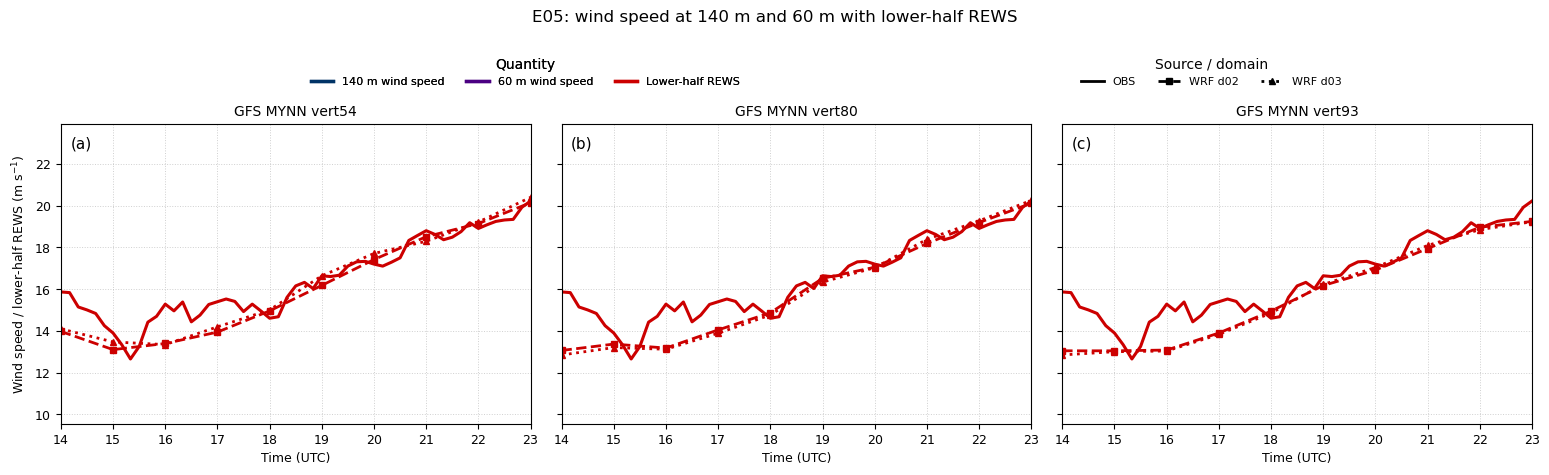

Saved: ./figures_E05_d02_d03_combined_WS_REWS/E05_gfs_mynn_d02_d03_WS140m_WS60m_lower_half_REWS_1x3.png
Saved: ./figures_E05_d02_d03_combined_WS_REWS/E05_gfs_mynn_d02_d03_WS140m_WS60m_lower_half_REWS_1x3.pdf


In [63]:
plot_combined_ws_rews_1x3()


Checking run directories...
FOUND   ERA5  vert54 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/era5_3dpbl
FOUND   ERA5  vert80 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/era5_3dpbl_vert80
FOUND   ERA5  vert93 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/era5_3dpbl_vert93
FOUND   GFS   vert54 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/gfs_3dpbl_vert54
FOUND   GFS   vert80 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/gfs_3dpbl_vert80
FOUND   GFS   vert93 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/gfs_3dpbl_vert93
FOUND   HRRR  vert54 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/hrrr_3dpbl_vert54
FOUND   HRRR  vert80 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/hrrr_3dpbl_vert80
FOUND   HRRR  vert93 : /glade/derecho/scratch/mhafsah/sensitivity_trial2/all_runs/hrrr_3dpbl_vert93

All nine run directories found.

WRF times: 10 points
OBS times: 55 points

ERA5

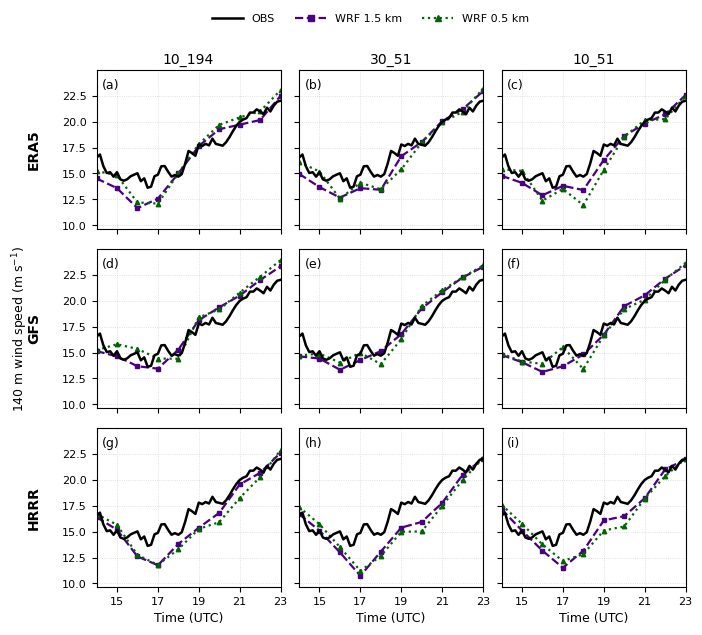


Saved:
./figures_E05_3dpbl_horizontal_resolution/E05_3DPBL_horizontal_resolution_140m_3x3.png
./figures_E05_3dpbl_horizontal_resolution/E05_3DPBL_horizontal_resolution_140m_3x3.pdf


In [10]:
# ============================================================
# 3D-PBL HORIZONTAL-RESOLUTION SENSITIVITY
# E05 — 60 m WIND SPEED
#
# 3 x 3 layout:
#
#                 10_194      30_51       10_51
# ERA5              (a)         (b)         (c)
# GFS               (d)         (e)         (f)
# HRRR              (g)         (h)         (i)
#
# Each panel:
#   OBS
#   WRF 1.5 km
#   WRF 0.5 km
#
# ERA5 / GFS:
#   d02 = 1.5 km
#   d03 = 0.5 km
#
# HRRR:
#   d01 = 1.5 km
#   d02 = 0.5 km
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

import os
import datetime as dt

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D

from wrf import destagger, interplevel


# ============================================================
# USER SETTINGS
# ============================================================

BASE_DIR = (
    "/glade/derecho/scratch/mhafsah/"
    "sensitivity_trial2/all_runs"
)


# ------------------------------------------------------------
# 3D-PBL run directories
#
# IMPORTANT:
# era5_3dpbl = ERA5 vert54
# ------------------------------------------------------------

RUN_DIRS = {

    "ERA5": {
        "vert54": os.path.join(
            BASE_DIR,
            "era5_3dpbl"
        ),
        "vert80": os.path.join(
            BASE_DIR,
            "era5_3dpbl_vert80"
        ),
        "vert93": os.path.join(
            BASE_DIR,
            "era5_3dpbl_vert93"
        ),
    },

    "GFS": {
        "vert54": os.path.join(
            BASE_DIR,
            "gfs_3dpbl_vert54"
        ),
        "vert80": os.path.join(
            BASE_DIR,
            "gfs_3dpbl_vert80"
        ),
        "vert93": os.path.join(
            BASE_DIR,
            "gfs_3dpbl_vert93"
        ),
    },

    "HRRR": {
        "vert54": os.path.join(
            BASE_DIR,
            "hrrr_3dpbl_vert54"
        ),
        "vert80": os.path.join(
            BASE_DIR,
            "hrrr_3dpbl_vert80"
        ),
        "vert93": os.path.join(
            BASE_DIR,
            "hrrr_3dpbl_vert93"
        ),
    },
}


# ------------------------------------------------------------
# Domain corresponding to each horizontal resolution
# ------------------------------------------------------------

FORCING_DOMAINS = {

    # forcing : [1.5-km domain, 0.5-km domain]

    "ERA5": ["d02", "d03"],

    "GFS": ["d02", "d03"],

    "HRRR": ["d01", "d02"],
}


# ------------------------------------------------------------
# Plot order
# ------------------------------------------------------------

FORCING_ORDER = [
    "ERA5",
    "GFS",
    "HRRR"
]

VERT_ORDER = [
    "vert54",
    "vert80",
    "vert93"
]


# ------------------------------------------------------------
# Labels corresponding to manuscript vertical configurations
# ------------------------------------------------------------

VERT_LABELS = {
    "vert54": "10_194",
    "vert80": "30_51",
    "vert93": "10_51",
}


# ------------------------------------------------------------
# LiDAR site
# ------------------------------------------------------------

LIDAR_LABEL = "E05"

LIDAR_LON = -72.72
LIDAR_LAT = 39.97


# ------------------------------------------------------------
# Observations
#
# Shape:
#   55 time steps x 10 heights
#
# Heights:
#   20, 40, ..., 200 m
# ------------------------------------------------------------

OBS_FILE = (
    "/glade/work/mhafsah/Analysis_Proj_1/"
    "WS_E05_OBS.npy"
)


HEIGHTS_M = np.array(
    [
        20,
        40,
        60,
        80,
        100,
        120,
        140,
        160,
        180,
        200
    ],
    dtype=float
)


# Height used for this sensitivity analysis
TARGET_HEIGHT = 140


# ------------------------------------------------------------
# Time settings
# ------------------------------------------------------------

DAY_STR = "2020-05-15"

START_HOUR = 14
END_HOUR = 23


# WRF files are hourly
WRF_DT_MINUTES = 60


# Observations are 10-minutely
OBS_DT_MINUTES = 10


# Plot all 10-min observations
OBS_STRIDE = 1


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUT_DIR = (
    f"./figures_{LIDAR_LABEL}_"
    "3dpbl_horizontal_resolution"
)

os.makedirs(
    OUT_DIR,
    exist_ok=True
)


# ============================================================
# PLOT STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "DejaVu Sans",

    "mathtext.fontset": "dejavusans",

    "font.size": 10,

    "axes.titlesize": 10,

    "axes.labelsize": 9,

    "xtick.labelsize": 8,

    "ytick.labelsize": 8,

    "legend.fontsize": 8,

    "figure.titlesize": 11,

    "pdf.fonttype": 42,

    "ps.fonttype": 42,
})


# ------------------------------------------------------------
# Wind-speed color
# ------------------------------------------------------------

COLOR_WS = "#4B0082"


# ------------------------------------------------------------
# Line styles by physical resolution
# ------------------------------------------------------------

STYLE_OBS = "-"

STYLE_1500M = "--"

STYLE_500M = ":"


# ============================================================
# TIME AND FILE HELPERS
# ============================================================

def make_times(
    day_str,
    start_hour,
    end_hour,
    dt_minutes
):
    """
    Make datetime objects from start_hour to end_hour inclusive.
    """

    t0 = dt.datetime.strptime(
        f"{day_str} {start_hour:02d}:00:00",
        "%Y-%m-%d %H:%M:%S"
    )

    t1 = dt.datetime.strptime(
        f"{day_str} {end_hour:02d}:00:00",
        "%Y-%m-%d %H:%M:%S"
    )

    times = []

    t = t0

    while t <= t1:

        times.append(t)

        t += dt.timedelta(
            minutes=dt_minutes
        )

    return times


def wrfout_path(
    run_dir,
    dom,
    time_obj
):
    """
    Build WRF output file path.

    Example:
      wrfout_d02_2020-05-15_15:00:00
    """

    ts = time_obj.strftime(
        "%Y-%m-%d_%H:%M:%S"
    )

    return os.path.join(
        run_dir,
        f"wrfout_{dom}_{ts}"
    )


def get_first_existing_file(
    run_dir,
    dom,
    wrf_times
):
    """
    Find first existing WRF output file for one run/domain.

    Used to obtain XLAT/XLONG and identify the nearest
    grid point to the LiDAR.
    """

    for t in wrf_times:

        f = wrfout_path(
            run_dir,
            dom,
            t
        )

        if os.path.exists(f):

            return f

    return None


# ============================================================
# GRID / LOCATION HELPERS
# ============================================================

def get_latlon(ds):
    """
    Read XLAT and XLONG.

    If a Time dimension exists, use Time=0.
    """

    lats = ds["XLAT"]
    lons = ds["XLONG"]

    if "Time" in lats.dims:

        lats = lats.isel(
            Time=0
        )

    if "Time" in lons.dims:

        lons = lons.isel(
            Time=0
        )

    return (
        np.asarray(lons),
        np.asarray(lats)
    )


def nearest_grid_point(
    lons,
    lats,
    target_lon,
    target_lat
):
    """
    Find nearest WRF mass-grid point to LiDAR location.

    Uses the same approximate-distance approach as
    the original extraction script.
    """

    km_lon = 85.0
    km_lat = 111.0

    latdiff_km = (
        np.abs(
            lats - target_lat
        )
        * km_lat
    )

    londiff_km = (
        np.abs(
            lons - target_lon
        )
        * km_lon
    )

    dist_km = np.sqrt(
        latdiff_km**2
        +
        londiff_km**2
    )

    j, i = np.where(
        dist_km
        ==
        np.nanmin(dist_km)
    )

    j = int(j[0])
    i = int(i[0])

    return (
        j,
        i,
        float(
            dist_km[j, i]
        )
    )


# ============================================================
# OBSERVATION PROFILE READER
# ============================================================

def load_ws_profile(path):
    """
    Load wind-speed profile array.

    Expected:
      shape = (time, height)

    Height columns:
      20, 40, ..., 200 m
    """

    arr = np.load(path)

    if arr.ndim != 2:

        raise ValueError(
            f"Expected 2-D array, "
            f"got shape {arr.shape}: {path}"
        )

    if arr.shape[1] == len(HEIGHTS_M):

        return arr.astype(float)

    if arr.shape[0] == len(HEIGHTS_M):

        print(
            f"Transposing array from "
            f"{arr.shape} to "
            f"{(arr.shape[1], arr.shape[0])}: "
            f"{path}"
        )

        return arr.T.astype(float)

    raise ValueError(
        f"Unexpected WS array shape "
        f"{arr.shape} in {path}. "
        f"Expected one dimension to match "
        f"{len(HEIGHTS_M)} height levels."
    )


def height_index(
    target_height_m
):
    """
    Return column index corresponding to target height.
    """

    idx = np.where(
        HEIGHTS_M
        ==
        float(target_height_m)
    )[0]

    if len(idx) == 0:

        raise ValueError(
            f"Height {target_height_m} m "
            "not found in HEIGHTS_M"
        )

    return int(
        idx[0]
    )


# ============================================================
# WRF FULL-PROFILE EXTRACTION
# ============================================================

# ============================================================
# WRF FULL-PROFILE EXTRACTION
# ============================================================

def extract_lidar_ws_profile(run_dir, dom, wrf_times):
    """
    Extract full LiDAR-location wind-speed profile
    from one WRF domain.

    Output:
      ws_profile.shape = (n_wrf_times, 10)

    Columns:
      20, 40, 60, ..., 200 m
    """

    first_file = get_first_existing_file(
        run_dir,
        dom,
        wrf_times
    )

    if first_file is None:

        print(
            f"WARNING: no files found for\n"
            f"  {run_dir}\n"
            f"  domain = {dom}"
        )

        return (
            np.full(
                (len(wrf_times), len(HEIGHTS_M)),
                np.nan
            ),
            np.nan,
            None,
            None
        )

    # ========================================================
    # Find nearest LiDAR grid point
    # ========================================================

    with xr.open_dataset(
        first_file,
        engine="netcdf4"
    ) as ds0:

        lon, lat = get_latlon(ds0)

        j_lidar, i_lidar, dist_km = nearest_grid_point(
            lon,
            lat,
            LIDAR_LON,
            LIDAR_LAT
        )

    print(
        f"{os.path.basename(run_dir)} | {dom}: "
        f"{LIDAR_LABEL} nearest index = "
        f"({j_lidar}, {i_lidar}), "
        f"distance = {dist_km:.3f} km"
    )

    # Storage:
    # time x requested height
    ws_profile = np.full(
        (len(wrf_times), len(HEIGHTS_M)),
        np.nan,
        dtype=float
    )

    # ========================================================
    # Loop through hourly WRF files
    # ========================================================

    for k, t in enumerate(wrf_times):

        fpath = wrfout_path(
            run_dir,
            dom,
            t
        )

        if not os.path.exists(fpath):

            print(
                f"  missing: {fpath}"
            )

            continue

        try:

            with xr.open_dataset(
                fpath,
                engine="netcdf4"
            ) as ds:

                # =================================================
                # Extract first/only Time record as NumPy arrays
                # =================================================

                PH = np.asarray(
                    ds["PH"].isel(Time=0)
                )

                PHB = np.asarray(
                    ds["PHB"].isel(Time=0)
                )

                HGT = np.asarray(
                    ds["HGT"].isel(Time=0)
                )

                U = np.asarray(
                    ds["U"].isel(Time=0)
                )

                V = np.asarray(
                    ds["V"].isel(Time=0)
                )

                # =================================================
                # Height above ground level
                #
                # PH/PHB:
                #   bottom_top_stag, south_north, west_east
                #
                # HGT:
                #   south_north, west_east
                # =================================================

                height_stag = (
                    (PH + PHB) / 9.81
                    -
                    HGT[np.newaxis, :, :]
                )

                # =================================================
                # Destagger winds to mass grid
                #
                # U shape:
                #   bottom_top, south_north, west_east_stag
                #
                # V shape:
                #   bottom_top, south_north_stag, west_east
                # =================================================

                u_destag = destagger(
                    U,
                    -1
                )

                v_destag = destagger(
                    V,
                    -2
                )

                # =================================================
                # Destagger height vertically
                #
                # Vertical dimension is axis 0 after Time removal.
                # =================================================

                height_destag = destagger(
                    height_stag,
                    0
                )

                # =================================================
                # Wind speed on mass grid
                # =================================================

                ws = np.sqrt(
                    u_destag**2
                    +
                    v_destag**2
                )

                # =================================================
                # Interpolate wind speed to requested heights
                # =================================================

                for h_idx, h in enumerate(HEIGHTS_M):

                    ws_interp = interplevel(
                        ws,
                        height_destag,
                        float(h),
                        meta=False
                    )

                    ws_interp = np.asarray(
                        ws_interp
                    )

                    ws_profile[
                        k,
                        h_idx
                    ] = ws_interp[
                        j_lidar,
                        i_lidar
                    ]

        except Exception as e:

            print(
                f"  failed {dom} {t}: {e}"
            )

    return (
        ws_profile,
        dist_km,
        j_lidar,
        i_lidar
    )
    # --------------------------------------------------------
    # Find nearest LiDAR grid point
    # --------------------------------------------------------

    ds0 = xr.open_dataset(
        first_file,
        engine="netcdf4"
    )

    lon, lat = get_latlon(
        ds0
    )

    (
        j_lidar,
        i_lidar,
        dist_km
    ) = nearest_grid_point(
        lon,
        lat,
        LIDAR_LON,
        LIDAR_LAT
    )

    ds0.close()


    print(
        f"{os.path.basename(run_dir)} | {dom}: "
        f"{LIDAR_LABEL} nearest index "
        f"= ({j_lidar}, {i_lidar}), "
        f"distance = {dist_km:.3f} km"
    )


    ws_profile = np.full(
        (
            len(wrf_times),
            len(HEIGHTS_M)
        ),
        np.nan,
        dtype=float
    )


    # --------------------------------------------------------
    # Loop through hourly WRF files
    # --------------------------------------------------------

    for k, t in enumerate(
        wrf_times
    ):

        fpath = wrfout_path(
            run_dir,
            dom,
            t
        )

        if not os.path.exists(
            fpath
        ):

            print(
                f"  missing: {fpath}"
            )

            continue


        ds = None

        try:

            ds = xr.open_dataset(
                fpath,
                engine="netcdf4"
            )


            # ------------------------------------------------
            # Height above ground level
            # ------------------------------------------------

            height = (
                (
                    ds["PH"][:]
                    +
                    ds["PHB"][:]
                )
                / 9.81
                -
                ds["HGT"][:]
            )


            # ------------------------------------------------
            # Raw staggered winds
            # ------------------------------------------------

            u = ds["U"]
            v = ds["V"]


            # ------------------------------------------------
            # Destagger U
            # ------------------------------------------------

            u_destag = destagger(
                u,
                3
            )

            u_destag = u_destag.rename(
                {
                    "west_east_stag":
                    "west_east"
                }
            )


            # ------------------------------------------------
            # Destagger V
            # ------------------------------------------------

            v_destag = destagger(
                v,
                2
            )

            v_destag = v_destag.rename(
                {
                    "south_north_stag":
                    "south_north"
                }
            )


            # ------------------------------------------------
            # Destagger height vertically
            # ------------------------------------------------

            height_destag = destagger(
                height,
                1
            )

            height_destag = (
                height_destag.rename(
                    {
                        "bottom_top_stag":
                        "bottom_top"
                    }
                )
            )


            # ------------------------------------------------
            # Wind speed on mass grid
            # ------------------------------------------------

            ws = np.sqrt(
                u_destag**2
                +
                v_destag**2
            )


            # ------------------------------------------------
            # Interpolate to requested heights
            # ------------------------------------------------

            for h_idx, h in enumerate(
                HEIGHTS_M
            ):

                ws_interp = interplevel(
                    ws,
                    height_destag,
                    float(h)
                )


                if "level" in ws_interp.coords:

                    ws_interp = (
                        ws_interp.drop_vars(
                            "level"
                        )
                    )


                val = ws_interp.isel(
                    south_north=j_lidar,
                    west_east=i_lidar
                ).values


                ws_profile[
                    k,
                    h_idx
                ] = (
                    np.asarray(val)
                    .squeeze()
                )


        except Exception as e:

            print(
                f"  failed "
                f"{dom} {t}: {e}"
            )


        finally:

            if ds is not None:

                try:

                    ds.close()

                except Exception:

                    pass


    return (
        ws_profile,
        dist_km,
        j_lidar,
        i_lidar
    )


# ============================================================
# CHECK RUN DIRECTORIES
# ============================================================

def check_run_directories():
    """
    Check whether all nine expected 3D-PBL run directories exist.
    """

    print(
        "\nChecking run directories..."
    )

    missing = []

    for forcing in FORCING_ORDER:

        for vert in VERT_ORDER:

            path = RUN_DIRS[
                forcing
            ][
                vert
            ]

            if os.path.isdir(path):

                print(
                    f"FOUND   "
                    f"{forcing:5s} "
                    f"{vert:6s} : "
                    f"{path}"
                )

            else:

                print(
                    f"MISSING "
                    f"{forcing:5s} "
                    f"{vert:6s} : "
                    f"{path}"
                )

                missing.append(
                    path
                )


    if len(missing) > 0:

        print(
            "\nWARNING:"
            "\nSome expected directories "
            "were not found."
        )

        print(
            "Check the directory names "
            "above before running the extraction.\n"
        )

        return False


    print(
        "\nAll nine run directories found.\n"
    )

    return True


# ============================================================
# MAIN 3 x 3 PLOTTING FUNCTION
# ============================================================

def plot_3dpbl_horizontal_resolution_3x3():

    # --------------------------------------------------------
    # Time arrays
    # --------------------------------------------------------

    wrf_times = make_times(
        DAY_STR,
        START_HOUR,
        END_HOUR,
        WRF_DT_MINUTES
    )

    obs_times = make_times(
        DAY_STR,
        START_HOUR,
        END_HOUR,
        OBS_DT_MINUTES
    )


    print(
        f"WRF times: "
        f"{len(wrf_times)} points"
    )

    print(
        f"OBS times: "
        f"{len(obs_times)} points"
    )


    # --------------------------------------------------------
    # Load observations
    # --------------------------------------------------------

    obs_profile = load_ws_profile(
        OBS_FILE
    )


    if len(obs_profile) != len(
        obs_times
    ):

        raise ValueError(
            f"OBS length mismatch: "
            f"obs profile has "
            f"{len(obs_profile)} points, "
            f"but obs_times has "
            f"{len(obs_times)} points."
        )


    target_idx = height_index(
        TARGET_HEIGHT
    )

    obs_ws = obs_profile[
        :,
        target_idx
    ]


    # --------------------------------------------------------
    # Extract model data
    #
    # model_data[forcing][vert]["1500m"]
    # model_data[forcing][vert]["500m"]
    # --------------------------------------------------------

    model_data = {}


    for forcing in FORCING_ORDER:

        model_data[
            forcing
        ] = {}


        dom_1500, dom_500 = (
            FORCING_DOMAINS[
                forcing
            ]
        )


        for vert in VERT_ORDER:

            run_dir = RUN_DIRS[
                forcing
            ][
                vert
            ]


            print(
                "\n"
                +
                "=" * 70
            )

            print(
                f"{forcing} | "
                f"{VERT_LABELS[vert]}"
            )

            print(
                f"Directory: {run_dir}"
            )

            print(
                f"1.5 km = {dom_1500}"
            )

            print(
                f"0.5 km = {dom_500}"
            )

            print(
                "=" * 70
            )


            # ------------------------------------------------
            # 1.5-km domain
            # ------------------------------------------------

            (
                profile_1500,
                dist_1500,
                j_1500,
                i_1500
            ) = extract_lidar_ws_profile(
                run_dir=run_dir,
                dom=dom_1500,
                wrf_times=wrf_times
            )


            # ------------------------------------------------
            # 0.5-km domain
            # ------------------------------------------------

            (
                profile_500,
                dist_500,
                j_500,
                i_500
            ) = extract_lidar_ws_profile(
                run_dir=run_dir,
                dom=dom_500,
                wrf_times=wrf_times
            )


            model_data[
                forcing
            ][
                vert
            ] = {

                "1500m":
                profile_1500[
                    :,
                    target_idx
                ],

                "500m":
                profile_500[
                    :,
                    target_idx
                ],

                "dist_1500":
                dist_1500,

                "dist_500":
                dist_500,

                "dom_1500":
                dom_1500,

                "dom_500":
                dom_500,
            }


    # --------------------------------------------------------
    # Determine common y-axis limits
    # --------------------------------------------------------

    all_values = [
        obs_ws
    ]


    for forcing in FORCING_ORDER:

        for vert in VERT_ORDER:

            all_values.append(
                model_data[
                    forcing
                ][
                    vert
                ][
                    "1500m"
                ]
            )

            all_values.append(
                model_data[
                    forcing
                ][
                    vert
                ][
                    "500m"
                ]
            )


    all_values = np.concatenate(
        [
            np.asarray(v).ravel()
            for v in all_values
        ]
    )


    all_values = all_values[
        np.isfinite(
            all_values
        )
    ]


    if len(all_values) == 0:

        raise ValueError(
            "No finite wind-speed values "
            "were extracted."
        )


    ymin = np.nanmin(
        all_values
    )

    ymax = np.nanmax(
        all_values
    )


    ypad = (
        0.08
        *
        (ymax - ymin)
    )


    if ypad == 0:

        ypad = 1.0


    ymin -= ypad
    ymax += ypad


    print(
        "\nShared y-axis limits:"
    )

    print(
        f"{ymin:.2f} to "
        f"{ymax:.2f} m s-1"
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,

        # Copernicus/WES full-width figure
        figsize=(6.85, 6.3),

        sharex=True,
        sharey=True
    )


    panel_counter = 0


    # --------------------------------------------------------
    # Plot all 9 panels
    # --------------------------------------------------------

    for row, forcing in enumerate(
        FORCING_ORDER
    ):

        for col, vert in enumerate(
            VERT_ORDER
        ):

            ax = axes[
                row,
                col
            ]


            # =================================================
            # OBS
            # =================================================

            ax.plot(

                obs_times[
                    ::OBS_STRIDE
                ],

                obs_ws[
                    ::OBS_STRIDE
                ],

                color="black",

                linestyle=
                STYLE_OBS,

                linewidth=1.8,

                zorder=3,

                label="OBS"
            )


            # =================================================
            # WRF 1.5 km
            # =================================================

            ax.plot(

                wrf_times,

                model_data[
                    forcing
                ][
                    vert
                ][
                    "1500m"
                ],

                color=
                COLOR_WS,

                linestyle=
                STYLE_1500M,

                linewidth=1.6,

                marker="s",

                markersize=3.0,

                zorder=2,

                label="WRF 1.5 km"
            )


            # =================================================
            # WRF 0.5 km
            # =================================================

            ax.plot(

                wrf_times,

                model_data[
                    forcing
                ][
                    vert
                ][
                    "500m"
                ],

                color=
                "#006400",

                linestyle=
                STYLE_500M,

                linewidth=1.6,

                marker="^",

                markersize=3.2,

                zorder=2,

                label="WRF 0.5 km"
            )


            # -------------------------------------------------
            # Axis limits
            # -------------------------------------------------

            ax.set_xlim(
                obs_times[0],
                obs_times[-1]
            )

            ax.set_ylim(
                ymin,
                ymax
            )


            # -------------------------------------------------
            # X-axis
            # -------------------------------------------------

            ax.xaxis.set_major_locator(
                mdates.HourLocator(
                    interval=2
                )
            )

            ax.xaxis.set_major_formatter(
                mdates.DateFormatter(
                    "%H"
                )
            )


            # -------------------------------------------------
            # Grid
            # -------------------------------------------------

            ax.grid(
                True,
                linestyle=":",
                linewidth=0.6,
                alpha=0.5
            )


            # -------------------------------------------------
            # Panel label
            # -------------------------------------------------

            panel_label = (
                f"("
                f"{chr(97 + panel_counter)}"
                f")"
            )


            ax.text(
                0.03,
                0.95,

                panel_label,

                transform=
                ax.transAxes,

                ha="left",
                va="top",

                fontsize=9
            )


            panel_counter += 1


            # -------------------------------------------------
            # Column headings
            # -------------------------------------------------

            if row == 0:

                ax.set_title(
                    VERT_LABELS[
                        vert
                    ],
                    pad=5
                )


            # -------------------------------------------------
            # Forcing label on first column
            # -------------------------------------------------

            if col == 0:

                ax.text(
                    -0.34,
                    0.50,

                    forcing,

                    transform=
                    ax.transAxes,

                    rotation=90,

                    ha="center",
                    va="center",

                    fontsize=10,
                    fontweight="bold"
                )


            # -------------------------------------------------
            # Bottom-row X labels
            # -------------------------------------------------

            if row == 2:

                ax.set_xlabel(
                    "Time (UTC)"
                )


    # ========================================================
    # SHARED Y LABEL
    # ========================================================

    fig.text(
        0.018,
        0.50,

        f"{TARGET_HEIGHT} m wind speed "
        "(m s$^{-1}$)",

        rotation=90,

        ha="center",
        va="center",

        fontsize=9
    )


    # ========================================================
    # SHARED LEGEND
    # ========================================================

    legend_handles = [

        Line2D(
            [0],
            [0],

            color="black",

            linestyle=
            STYLE_OBS,

            linewidth=1.8,

            label="OBS"
        ),


        Line2D(
            [0],
            [0],

            color=
            COLOR_WS,

            linestyle=
            STYLE_1500M,

            linewidth=1.6,

            marker="s",

            markersize=4,

            label="WRF 1.5 km"
        ),


        Line2D(
            [0],
            [0],

            color=
            "#006400",

            linestyle=
            STYLE_500M,

            linewidth=1.6,

            marker="^",

            markersize=4,

            label="WRF 0.5 km"
        ),
    ]


    fig.legend(

        handles=
        legend_handles,

        loc=
        "upper center",

        bbox_to_anchor=
        (0.53, 1.015),

        ncol=3,

        frameon=False,

        handlelength=2.8,

        columnspacing=1.8
    )


    # ========================================================
    # LAYOUT
    # ========================================================

    plt.subplots_adjust(

        left=0.13,

        right=0.99,

        bottom=0.09,

        top=0.91,

        wspace=0.10,

        hspace=0.13
    )


    # ========================================================
    # SAVE
    # ========================================================

    out_png = os.path.join(

        OUT_DIR,

        f"{LIDAR_LABEL}_"
        f"3DPBL_"
        f"horizontal_resolution_"
        f"{TARGET_HEIGHT}m_"
        "3x3.png"
    )


    out_pdf = os.path.join(

        OUT_DIR,

        f"{LIDAR_LABEL}_"
        f"3DPBL_"
        f"horizontal_resolution_"
        f"{TARGET_HEIGHT}m_"
        "3x3.pdf"
    )


    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )


    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )


    plt.show()


    print(
        f"\nSaved:\n{out_png}"
    )

    print(
        f"{out_pdf}"
    )


# ============================================================
# RUN
# ============================================================

directories_ok = (
    check_run_directories()
)


if directories_ok:

    plot_3dpbl_horizontal_resolution_3x3()

else:

    print(
        "\nFigure was NOT generated "
        "because one or more run "
        "directories were not found."
    )